## Homework 8

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import HuberRegressor, LinearRegression
from sklearn.metrics import r2_score, root_mean_squared_error

### 1. Load, encode, and scale

In [2]:
df = pd.read_excel('../data_manufacturing.xlsx')
y = df['Dissolution'].values
X_df = df.drop(columns=['Dissolution'])

# One-Hot encode categoricals (drop one level each), pass continuous columns through
string_col_indices = [i for i, c in enumerate(X_df.columns)
                      if X_df[c].dtype == object or str(X_df[c].dtype) == 'str']
pre = ColumnTransformer(
    [('ohe', OneHotEncoder(drop='first', sparse_output=False), string_col_indices)],
    remainder='passthrough')
X = pre.fit_transform(X_df)
feature_names = [n.replace('ohe__', '').replace('remainder__', '')
                 for n in pre.get_feature_names_out()]

# Scale every column to mu=0, sigma=1
X_scaled = StandardScaler().fit_transform(X)
print('Scaled design matrix:', X_scaled.shape)

Scaled design matrix: (90, 19)


### 2. Baseline OLS vs. default Huber

In [3]:
ols = LinearRegression().fit(X_scaled, y)
y_ols = ols.predict(X_scaled)

# default epsilon=1.35 (sklearn default); alpha is a small L2 penalty
huber = HuberRegressor(epsilon=1.35, alpha=0.0001, max_iter=2000).fit(X_scaled, y)
y_hub = huber.predict(X_scaled)

print(f'{"Model":<8}{"R^2":>10}{"RMSE":>10}{"flagged":>10}')
print(f'{"OLS":<8}{r2_score(y, y_ols):>10.4f}{root_mean_squared_error(y, y_ols):>10.4f}{"-":>10}')
print(f'{"Huber":<8}{r2_score(y, y_hub):>10.4f}{root_mean_squared_error(y, y_hub):>10.4f}'
      f'{int(huber.outliers_.sum()):>10}')

# how much do the coefficients move?
print(f'\nMax |coef_OLS - coef_Huber| = {np.abs(ols.coef_ - huber.coef_).max():.4f}')

Model          R^2      RMSE   flagged
OLS         0.9196    1.0103         -
Huber       0.9119    1.0575        31

Max |coef_OLS - coef_Huber| = 0.1803


At the default $\epsilon = 1.35$ Huber flags ~31 points as lying in its linear (robust) region. But the main result is that OLS and Huber agree closely, meaning that R² and RMSE are almost identical (0.920 vs 0.912) and no coefficient moves by more than ~0.18. If the data contained bad leverage points, down-weighting them would shift the coefficients substantially, which is not happening here.

### 3. Influence of the cutoff parameter $\epsilon$

$\epsilon$ controls where the loss switches from quadratic to linear. Small $\epsilon$ → almost every residual is treated robustly (Huber behaves like least-absolute-deviation regression); large $\epsilon$ → the linear region never kicks in and Huber reduces to OLS.

In [4]:
epsilons = [1.05, 1.1, 1.2, 1.35, 1.5, 2.0, 3.0, 5.0]
rows = []
for eps in epsilons:
    h = HuberRegressor(epsilon=eps, alpha=0.0001, max_iter=3000).fit(X_scaled, y)
    yp = h.predict(X_scaled)
    rows.append({'epsilon': eps,
                 'R2': r2_score(y, yp),
                 'RMSE': root_mean_squared_error(y, yp),
                 'n_flagged': int(h.outliers_.sum()),
                 'max_coef_diff_vs_OLS': np.abs(h.coef_ - ols.coef_).max()})
sweep = pd.DataFrame(rows)
print(sweep.to_string(index=False))

 epsilon       R2     RMSE  n_flagged  max_coef_diff_vs_OLS
    1.05 0.910770 1.064165         79              0.178006
    1.10 0.908217 1.079279         64              0.241091
    1.20 0.910955 1.063060         47              0.204520
    1.35 0.911892 1.057450         31              0.180327
    1.50 0.913628 1.046979         24              0.161188
    2.00 0.917079 1.025854          8              0.097347
    3.00 0.919507 1.010722          2              0.024006
    5.00 0.919581 1.010255          0              0.000004


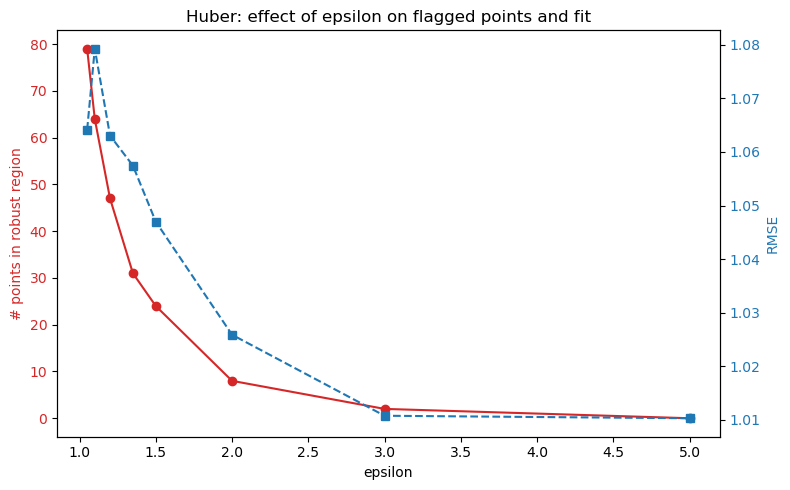

In [5]:
fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(sweep['epsilon'], sweep['n_flagged'], 'o-', color='tab:red',
         label='# flagged points')
ax1.set_xlabel('epsilon'); ax1.set_ylabel('# points in robust region', color='tab:red')
ax1.tick_params(axis='y', labelcolor='tab:red')

ax2 = ax1.twinx()
ax2.plot(sweep['epsilon'], sweep['RMSE'], 's--', color='tab:blue', label='RMSE')
ax2.set_ylabel('RMSE', color='tab:blue'); ax2.tick_params(axis='y', labelcolor='tab:blue')
plt.title('Huber: effect of epsilon on flagged points and fit')
plt.tight_layout(); plt.show()

As $\epsilon$ increases, the number of flagged points falls to zero and RMSE/R² converge exactly to the OLS values (RMSE → 1.010, R² → 0.920). The whole Huber-to-OLS transition is smooth and monotone, with no regime where the robust fit is dramatically better than OLS.

### 4. Residual comparison

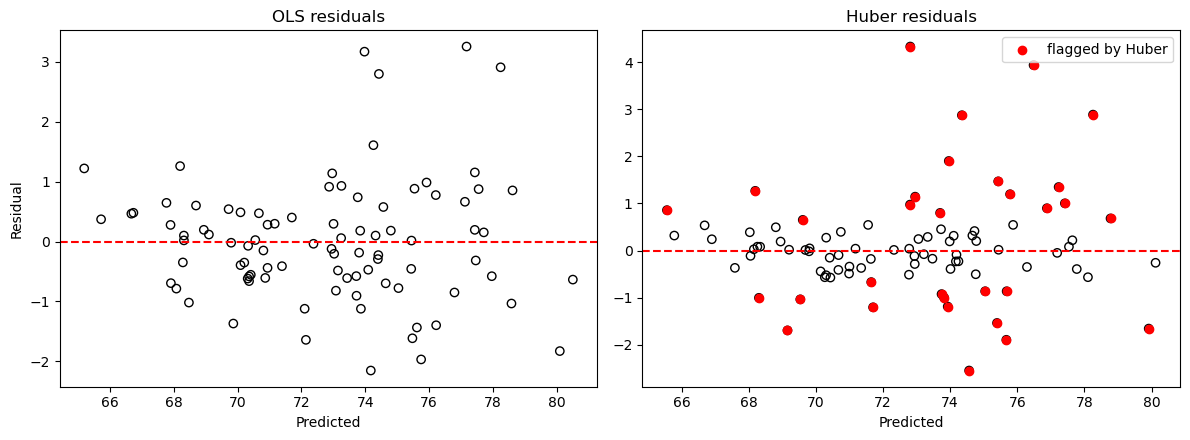

In [6]:
res_ols = y - y_ols
res_hub = y - y_hub

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(y_ols, res_ols, edgecolor='k', facecolor='none')
axes[0].axhline(0, color='red', ls='--'); axes[0].set_title('OLS residuals')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Residual')

axes[1].scatter(y_hub, res_hub, edgecolor='k', facecolor='none')
# highlight the points Huber treats robustly
axes[1].scatter(y_hub[huber.outliers_], res_hub[huber.outliers_],
                color='red', label='flagged by Huber')
axes[1].axhline(0, color='red', ls='--'); axes[1].set_title('Huber residuals')
axes[1].set_xlabel('Predicted'); axes[1].legend()
plt.tight_layout(); plt.show()

### 5. Discussion

#### Effect of the parameterisation
- $\epsilon$ is the decisive parameter. At small $\epsilon$ (≈ 1.05) almost all points (≈ 88/90) fall in the linear region and Huber behaves like LAD regression. At large $\epsilon$ (≥ 5) no point is treated robustly and Huber is identical to OLS. In between, the flagged count and RMSE change smoothly.
- $\alpha$ is only a small L2 penalty here, with this many observations relative to features it has negligible effect on the fit and is left near its default.

#### What this says about outliers
The key diagnostic is not the raw count of flagged points: at $\epsilon = 1.35$ Huber flags ~31/90, but that simply reflects how many residuals exceed 1.35 robust standard deviations, which is large only because the cutoff is low. The decisive observations are:

1. The coefficients are stable: OLS and Huber coefficients differ by at most ~0.18, robustly down-weighting the "large-residual" points does not move the model.
2. The fit metrics converge: as $\epsilon$ grows, Huber's R² and RMSE rise smoothly to exactly the OLS values. The robust and non-robust fits describe the same surface.

Together these mean the data contains no influential outliers, in particular no bad leverage points. If bad leverage points were present, OLS would be tilted toward them and Huber would visibly disagree (by having different coefficients, much lower robust RMSE). Instead, the flagged points are ordinary scatter in the tails of an approximately symmetric residual distribution.

#### Practical conclusion
For this dataset, OLS (from Exercise 3) is already adequate, because there is nothing for a robust method to correct. The value of running Huber here is precisely the negative result: it confirms the OLS fit is not being driven by a handful of contaminating observations.